In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [86]:
total_steps = 300000
# path_HYPER_seq2_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/HYPER/bg_2500_net1/beta_0.3/eh_step_0.00007/fixed_goals-actual"
path_HYPER_seq2_fixed_goals_actual_compare = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/HYPER/bg_2500_net1/beta_0.3/eh_step_0.00007/fixed_goals-actual/compare"
path_HYPER_seq2_fixed_goals_actual_beta07_compare = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare"
path_oracle_seq2_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/SAC/actor_step_size_0.0007/critic_stepsize_0.0007/init_temperature_0.1/reward_step_0.0003/fixed_goals-actual"
# path_HYPER_seq4_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.3/eh_step_0.00007/fixed_goals-actual"
path_HYPER_seq4_fixed_goals_actual_compare = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.3/eh_step_0.00007/fixed_goals-actual/compare"
path_HYPER_seq4_fixed_goals_actual_beta07_compare = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare"
path_oracle_seq4_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/SAC/actor_step_size_0.0007/critic_stepsize_0.0007/init_temperature_0.1/reward_step_0.0003/fixed_goals-actual"

path_DGR_seq2_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/DGR/prev_generator/gen_update_freq_5/lambda_vae_1.0/sac_stepsize_0.0007/compare"
path_DGR_seq2_fixed_goals_actual_beta05 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/DGR/prev_generator/gen_update_freq_5/lambda_vae_5.0/sac_stepsize_0.0007/compare"
path_SI_seq2_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/r_step_0.0005/beta_0.1/compare"
path_SI_seq2_fixed_goals_actual_beta1 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/r_step_0.0005/beta_1.0/compare"
path_SI_seq2_fixed_goals_actual_beta10 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/r_step_0.0005/beta_10.0/compare"
path_scratch = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/LFS_HNET/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare"
path_PEBBLE = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/FT_normal/bg_2500_net1/beta_0.0/eh_step_0.00007/fixed_goals-actual/compare"

# path_HYPER_seq4_fixed_goals_actual_small_emb_lr = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.3/eh_step_0.00001/fixed_goals-actual"
algs = ['/HYPER', '/SI', '/DGR', '/Oracle']
num_runs = 10

In [87]:
"""
This function plots a single plot. It has some title.
Each plot can have multiple curves (and corresponding labels and colors).
Each curve consists of the sample mean of several runs and confidence interval.
"""
from scipy import stats
def plot_single(steps, stuff, legend, colors, title, figsize, xylabels, plot_mu_ci, lims, t_value, vert_lines=None, hor_lines=None, legend_loc=None, x_ticks=None, x_labels=None, summarize_plot=True):
    # 1. steps is an np array. If you want to plot x-axis from [a, b], steps == np.array([a, a+1, a+2, ..., b-1, b])
    # 2. stuff contains the data for the y-axis. It is an np array.
    # stuff should have shape of type: (ncurves, nruns, num of elements in each run i.e. the y values)
    # ncurves means the number of curves you want in a particular plot
    # nruns means the number of runs you want EACH CURVE to be averaged over
    # num of elements are the y-values for each run inside each curve
    # 3. legends is a list with "ncurves" elements, with one element for each curve. Each element is the legend label (a string) for each curve. 
    # 4. colors is a list with "ncurves" elements, with one element for each curve. Each element is the hash value (a string) for the color for each curve. 
    # 5. title is a string with the title for the plot
    # 6. figsize gives the size of the plot in the form of a tuple (A,B), where A and B and length and breadth
    # 7. xylabels is a list with 2 strings containing the label for x and y axis respecitvely
    fig = plt.figure(figsize=figsize)
    nruns = stuff.shape[1]
    ymin_seen = np.inf
    ymax_seen = -np.inf
    for i in range(stuff.shape[0]): # for each curve
        if plot_mu_ci:
            sample_mean = np.mean(stuff[i], axis=0) # compute the sample mean for nruns for curve[i]
            sample_std = np.std(stuff[i], axis=0, ddof=1) # compute the sample std for nruns for curve[i]
            t_statistic_std_error = t_value * sample_std/np.sqrt(nruns) # compute the 1.98 * std_error; std_error = sample_std/sqrt(nruns)
            upper, lower = sample_mean + t_statistic_std_error, sample_mean - t_statistic_std_error
            ymin_seen = min(ymin_seen, lower.min())
            ymax_seen = max(ymax_seen, upper.max())
            plt.plot(steps, sample_mean, color=colors[i], label=legend[i])
            plt.fill_between(steps, lower, upper, color=colors[i], alpha=0.1)
        else:
            plt.plot(steps, stuff[i].squeeze(), color=colors[i], label=legend[i])
    plt.title(title, size=20)
    plt.xlabel(xylabels[0], fontsize=20)
    plt.ylabel(xylabels[1], fontsize=20)
    plt.xticks(ticks=x_ticks, labels=x_labels, fontsize=20)
    plt.legend(loc='lower right' if legend_loc is None else legend_loc, prop={'size': 18})
    if vert_lines is not None:
        for vl in vert_lines:
            plt.axvline(x=vl, linestyle='--', color='black')
    if hor_lines is not None:
        for hl in hor_lines:
            plt.axhline(y=hl, linestyle='--', color='black')
    lims = [ymin_seen, ymax_seen]
    if lims is not None:
        plt.gca().set_ylim(top=lims[1], bottom=lims[0])
        
    
    if summarize_plot:
        print("\n=== Summary Metrics (Stability ) ===")
        stability_values = {}
        for i in range(len(stuff)):
            curve = np.array(stuff[i])          # shape: (nruns, T)
            nruns, T = curve.shape

            
            final_indices = [(j+1)*T//num_tasks - 1 for j in range(num_tasks)]
            print(final_indices)
            final_vals = curve[:, final_indices]
            # print(final_vals)
            # --- Stability: average performance on past tasks ---
            # assume past tasks occupy timesteps [0 : T-1]
            stability_runs = final_vals.mean(axis=1)
            stability_mean = np.mean(stability_runs)
            stability_ci = t_value * (np.std(stability_runs, ddof=1) / np.sqrt(nruns))

            # print in requested LaTeX-like format: $S\!\pm\!\delta$
            print(f"{legend[i]} | ${stability_mean:.1f}\\!\\pm\\!{stability_ci:.1f}$")
            stability_values[legend[i]] = stability_runs
            
        hyper_scores = stability_values["HYPER"]
        for i in stability_values:
            # print(f"{i} scores: {stability_values[i]}")
            t_stat, p_val = stats.ttest_ind(hyper_scores, stability_values[i], equal_var=False)
            print(f"P-value for {i}: {p_val}")

    # if summarize_plot:
    #     summary_runs = (np.abs(stuff[0] - stuff[1]).sum(axis=1)) / len(task_sequence)
    #     mean = np.mean(summary_runs)
    #     ci = t_value * (np.std(summary_runs, ddof=1)/np.sqrt(nruns))
    #     print(f'Mean difference between task and final (averaged across {nruns} runs) = {mean} \u00B1 {ci} | ({mean - ci}, {mean + ci})')
    #     fig.text(.5, -0.03, f'Mean difference between task and final (averaged across {nruns} runs) = {mean} \u00B1 {ci} | ({mean - ci}, {mean + ci})', ha='center', fontsize=15, weight='bold')

In [88]:
def compute_tuple_eval(path, what_to_plot):
    stuff_all_runs_e = []
    for run in range(num_runs):
        eval_csv_path = path + '/Run_{}'.format(run+1) + '/eval.csv'
        # print(eval_csv_path)
        eval_csv = pd.read_csv(eval_csv_path)
        avg_true_episode_returns_e = eval_csv[what_to_plot].values
        stuff_all_runs_e.append(avg_true_episode_returns_e)
    stuff_all_runs_e = np.array(stuff_all_runs_e)
    return stuff_all_runs_e

In [89]:
def compute_tuple_train(path, what_to_plot):
    stuff_all_runs_t = []
    for run in range(num_runs):
        train_csv_path = path + '/Run_{}'.format(run+1) + '/train.csv'
        print(eval_csv_path)
        eval_csv = pd.read_csv(eval_csv_path)
        avg_true_episode_returns_t = []
        for task in range(len(task_idx)):

            avg_true_episode_returns_t.extend(train_csv[what_to_plot].values[task*(total_steps//500):(task+1)*(total_steps//500)])

        stuff_all_runs_t.append(avg_true_episode_returns_t)
    stuff_all_runs_t = np.array(stuff_all_runs_t)
    return stuff_all_runs_t

In [90]:
def plot_subplots_mod2(nrows, ncols, steps, stuff, legends, colors, titles, commontitle, figsize, xylabels, plot_mu_ci, lims, t_value, legend_loc=None, plot_grids=None, vert_lines=None, horz_lines=None, plot_dots=False, x_ticks=None, x_labels=None):
    figs, axs = plt.subplots(nrows, ncols, figsize=figsize)
    if axs.ndim == 1:
        if nrows == 1:
            axs = axs.reshape(1, axs.shape[0])
        else:
            axs = axs.reshape(axs.shape[0], 1)
    plt.suptitle(commontitle, weight='bold', size=15)
    nsubplots = len(stuff)
    nruns = stuff[0][0].shape[0]
    for plot in range(nsubplots):
        ncurves = len(stuff[plot])
        row, col = plot // ncols, plot % ncols
        for curve in range(ncurves):
            if plot_mu_ci:
                sample_mean = np.mean(stuff[plot][curve], axis=0) # compute the sample mean for nruns for curve[i]
                sample_std = np.std(stuff[plot][curve], axis=0, ddof=1) # compute the sample std for nruns for curve[i]
                t_statistic_std_error = t_value * sample_std/np.sqrt(nruns) # compute the 1.98 * std_error; std_error = sample_std/sqrt(nruns)
                if plot_dots[plot]:
                    axs[row, col].plot(steps[plot][curve], sample_mean, color=colors[curve], label=legends[plot][curve], marker='o')
                else:
                    axs[row, col].plot(steps[plot][curve], sample_mean, color=colors[curve], label=legends[plot][curve])
                axs[row, col].fill_between(steps[plot][curve], sample_mean-t_statistic_std_error, sample_mean+t_statistic_std_error, 
                                            color=colors[curve], alpha=0.1)
            else:
                axs[row, col].plot(steps[plot][curve], stuff[plot][curve], color=colors[curve], label=legends[plot][curve])
        axs[row, col].legend(loc='lower right' if legend_loc[plot] is None else legend_loc[plot])
        if lims[plot] is not None:
            axs[row, col].set_ylim(lims[plot])
        axs[row, col].set_title(titles[plot], size=13)
        if plot_grids[plot]:
            axs[row, col].grid()
        if vert_lines is not None:
            for vl in range(len(vert_lines[plot])):
                axs[row, col].axvline(x=vert_lines[plot][vl], linestyle='--', color='black')
        if horz_lines is not None:
            axs[row, col].axhline(y=horz_lines[plot], linestyle='--', color='black')

        # axs[row, col].set_xticks(x_ticks, fontsize=18)
        # axs[row, col].set_xticklabels(x_labels, fontsize=18)
    # set x and y labels
    for i, ax in enumerate(axs.flat):
        ax.set(xlabel=xylabels[i][0], ylabel=xylabels[i][1])
    # Hide x labels and tick labels for top plots and y ticks for right plots.
    # for ax in axs.flat:
    #     ax.label_outer()

In [91]:
num_runs = 10
task_steps = 300000
num_tasks = 3
x_ticks = [150000*(2*i-1) for i in range(1, num_tasks + 1)]
# x_labels = ["push-wall-v2", "shelf-place-v2", "push-back-v2"]
# x_labels = ["reach-v2","drawer-open-v2", "reach-wall-v2" ]
x_labels = ["reach-v2", "drawer-open-v2", "reach-wall-v2"]
task_idx = x_labels

# /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/mw_reach-v2/HYPER/bg_2000_net1/beta_0.75/eh_step_0.0005
# eval_csv_path = path + algs[0] + '/bg_2000_net1/beta_0.75/eh_step_0.0005' + '/Run_1/eval.csv'



In [92]:
eval_csv_path = path_HYPER_seq4_fixed_goals_actual_beta07_compare + '/Run_1/eval.csv'
eval_csv = pd.read_csv(eval_csv_path)
task_index = eval_csv['task_index'].values
steps_eval = eval_csv['step (eval called at this step)'].values
steps_plot = task_index * task_steps + steps_eval
print(steps_plot.shape)

train_csv_path = path_HYPER_seq4_fixed_goals_actual_beta07_compare + '/Run_1/train.csv'
train_csv = pd.read_csv(train_csv_path)
task_index = train_csv['task_index'].values
steps_train = train_csv['episode'].values *500
# steps_train = [1000*i for i in (steps_train)]
steps_plot_train = task_index * task_steps + steps_train
print(steps_train.shape)

stuff_all_curves = []
stuff_all_curves.append(compute_tuple_eval(path=path_HYPER_seq4_fixed_goals_actual_beta07_compare , what_to_plot='average_true_episode_return_final'))
# stuff_all_curves.append(compute_tuple_eval(path, what_to_plot='average_true_episode_return'))
stuff_all_curves = np.array(stuff_all_curves)

(93,)
(1740,)


In [93]:
# # stuff_all_curves_03_075 = compute_tuple_eval(path=path_03_75, what_to_plot='average_true_episode_return')
# # stuff_all_curves_SI = compute_tuple_eval(path=path_SI, what_to_plot='average_true_episode_return')
# # stuff_all_curves_ER = compute_tuple_eval(path=path_ER, what_to_plot='average_true_episode_return')
# stuff_all_curves_oracle = compute_tuple_eval(path=path_oracle, what_to_plot='average_true_episode_return')
# stuff_all_curves_03_50 = compute_tuple_eval(path=path_03_50, what_to_plot='average_true_episode_return')
# stuff_all_curves_03_25 = compute_tuple_eval(path=path_03_25, what_to_plot='average_true_episode_return')
# stuff_all_curves_03_075_1 = compute_tuple_eval(path=path_03_75_1, what_to_plot='average_true_episode_return')
# stuff_all_curves_03_50_1 = compute_tuple_eval(path=path_03_50_1, what_to_plot='average_true_episode_return')
# stuff_all_curves_03_25_1 = compute_tuple_eval(path=path_03_25_1, what_to_plot='average_true_episode_return')
# stuff_all_curves_03_075_01 = compute_tuple_eval(path=path_03_75_01, what_to_plot='average_true_episode_return')
# stuff_all_curves_03_50_01 = compute_tuple_eval(path=path_03_50_01, what_to_plot='average_true_episode_return')
# stuff_all_curves_03_25_01 = compute_tuple_eval(path=path_03_25_01, what_to_plot='average_true_episode_return')
# stuff_all_curves_SI_01 = compute_tuple_eval(path=path_SI_01, what_to_plot='average_true_episode_return')
# stuff_all_curves_SI_1 = compute_tuple_eval(path=path_SI_1, what_to_plot='average_true_episode_return')
# stuff_all_curves_SI_10 = compute_tuple_eval(path=path_SI_10, what_to_plot='average_true_episode_return')
# stuff_all_curves_DGR_1 = compute_tuple_eval(path=path_DGR_1, what_to_plot='average_true_episode_return')
# stuff_all_curves_DGR_5 = compute_tuple_eval(path=path_DGR_5, what_to_plot='average_true_episode_return')

# stuff_all_curves_oracle.shape, stuff_all_curves_03_50.shape, stuff_all_curves.shape

In [94]:
plot_mu_ci = True
legend = ['r_step=0.0003', 'r_step=0.0007']
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC', '#3E2723', '#DE970B', '#964B00', '#FF00FF']
title = f'Continual algorithms (Expanded) | Task variation in target | {num_runs} runs CIs | Running 15 episodes every 10K steps \nhdim=64,r_bs=128,bg=3000,qbs=50 \nAverage True Return | LFS'
xylabels = ['Environment steps', 'Average episodic return \n (15 episodes every 10K steps)']

t_value = 1.96
figsize = (25, 7)
lims = None
vert_lines = [task_steps * i for i in range(1, num_tasks + 1)]
hor_lines = [-5000, 0]
summarize_plot=False


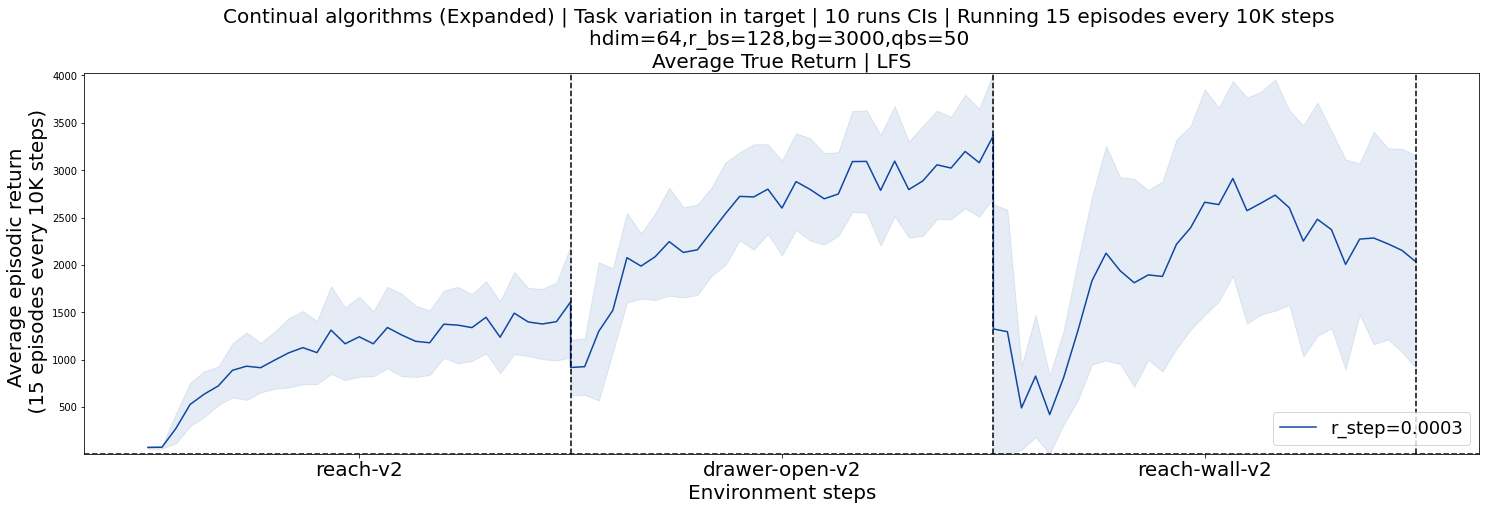

In [95]:
plot_single(steps_plot, stuff_all_curves, legend, colors, title, figsize, xylabels, plot_mu_ci, lims, t_value, vert_lines=vert_lines, hor_lines=hor_lines, x_ticks=x_ticks, x_labels=x_labels, summarize_plot=summarize_plot)


In [96]:
print(compute_tuple_train(path_HYPER_seq4_fixed_goals_actual_beta07_compare, 'true_episode_return_final').shape)
# compute_tuple_train(path_03_50, 'true_episode_return').shape

/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Use

In [97]:
# compute_tuple_train(path_HYPER_seq2_fixed_goals_actual_compare, 'true_episode_return_final').shape
    

In [98]:
# compute_tuple_train(path_HYPER_seq4_small_embhnet_lr, 'true_episode_return').shape

In [99]:
# compute_tuple_train(path_oracle_seq4_fixed_goals_actual, 'true_episode_return').shape

In [100]:
(compute_tuple_train(path_oracle_seq2_fixed_goals_actual, 'true_episode_return_final').shape, compute_tuple_train(path_HYPER_seq2_fixed_goals_actual_compare, 'true_episode_return_final').shape)

/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Use

((10, 1740), (10, 1740))

# True episode return vs step

/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/compare/Run_1/eval.csv
/Use

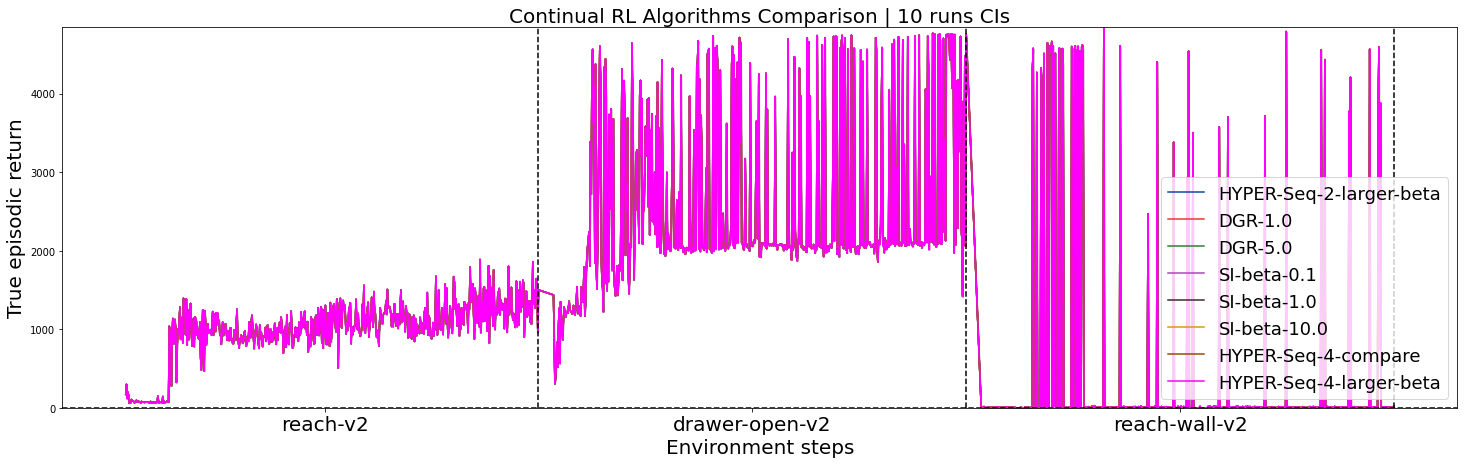

In [101]:
# Prepare data for all algorithms
stuff_all_curves = [
  
    # compute_tuple_train(path_HYPER_seq2_fixed_goals_actual_compare, 'true_episode_return_final'),
    # compute_tuple_train(path_oracle_seq2_fixed_goals_actual, 'true_episode_return'),
    compute_tuple_train(path_HYPER_seq2_fixed_goals_actual_beta07_compare, 'true_episode_return_final'),
    compute_tuple_train(path_DGR_seq2_fixed_goals_actual, 'true_episode_return_final'),
    compute_tuple_train(path_DGR_seq2_fixed_goals_actual_beta05, 'true_episode_return_final'),
    compute_tuple_train(path_SI_seq2_fixed_goals_actual, 'true_episode_return_final'),
    compute_tuple_train(path_SI_seq2_fixed_goals_actual_beta1, 'true_episode_return_final'),
    compute_tuple_train(path_SI_seq2_fixed_goals_actual_beta10, 'true_episode_return_final'),
    compute_tuple_train(path_scratch, 'true_episode_return_final'),
    compute_tuple_train(path_PEBBLE, 'true_episode_return_final'),
    # compute_tuple_train(path_HYPER_seq4_fixed_goals_actual_compare, 'true_episode_return_final'),
    # compute_tuple_train(path_HYPER_seq4_fixed_goals_actual_beta07_compare, 'true_episode_return_final'),
    # compute_tuple_train(path_oracle_seq4_fixed_goals_actual, 'true_episode_return'),

]
stuff_all_curves = np.array(stuff_all_curves)

print(stuff_all_curves.shape)

# legend = ['0.001', '0.0003-0.75', '0.0003-0.50', '0.0003-0.25', 'oracle']
legend = [
    
    # 'HYPER-Seq-2-compare',
    'HYPER-Seq-2-larger-beta',
    'DGR-1.0',
    'DGR-5.0',
    'SI-beta-0.1',
    'SI-beta-1.0',
    'SI-beta-10.0',
    # 'oracle-Seq-2',
    
    'HYPER-Seq-4-compare',
    'HYPER-Seq-4-larger-beta',
    'PEBBLE',

    # 'oracle-Seq-4',

]
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC', '#3E2723', '#DE970B', '#964B00', '#FF00FF', '#8B0000', '#4682B4', '#FFD700']
title = f'Continual RL Algorithms Comparison | {num_runs} runs CIs'
xylabels = ['Environment steps', 'True episodic return']

plot_single(
    steps_plot_train,
    stuff_all_curves,
    legend,
    colors,
    title,
    figsize,
    xylabels,
    plot_mu_ci,
    lims,
    t_value,
    vert_lines=vert_lines,
    hor_lines=hor_lines,
    x_ticks=x_ticks,
    x_labels=x_labels,
    summarize_plot=False
)

# Eval Plots

(7, 10, 93)

=== Summary Metrics (Stability ) ===
[30, 61, 92]
HYPER | $3423.4\!\pm\!453.1$
[30, 61, 92]
DGR-1.0 | $1920.1\!\pm\!417.9$
[30, 61, 92]
DGR-5.0 | $2231.1\!\pm\!382.3$
[30, 61, 92]
SI-0.1 | $1775.8\!\pm\!374.2$
[30, 61, 92]
SI-1.0 | $1897.0\!\pm\!385.3$
[30, 61, 92]
SI-10.0 | $1708.7\!\pm\!211.1$
[30, 61, 92]
Scratch | $1656.4\!\pm\!291.6$
P-value for HYPER: 1.0
P-value for DGR-1.0: 0.00015233519985795893
P-value for DGR-5.0: 0.001001396386059776
P-value for SI-0.1: 3.646806321887496e-05
P-value for SI-1.0: 9.377451354910157e-05
P-value for SI-10.0: 1.5776278285151704e-05
P-value for Scratch: 1.0153918189137169e-05


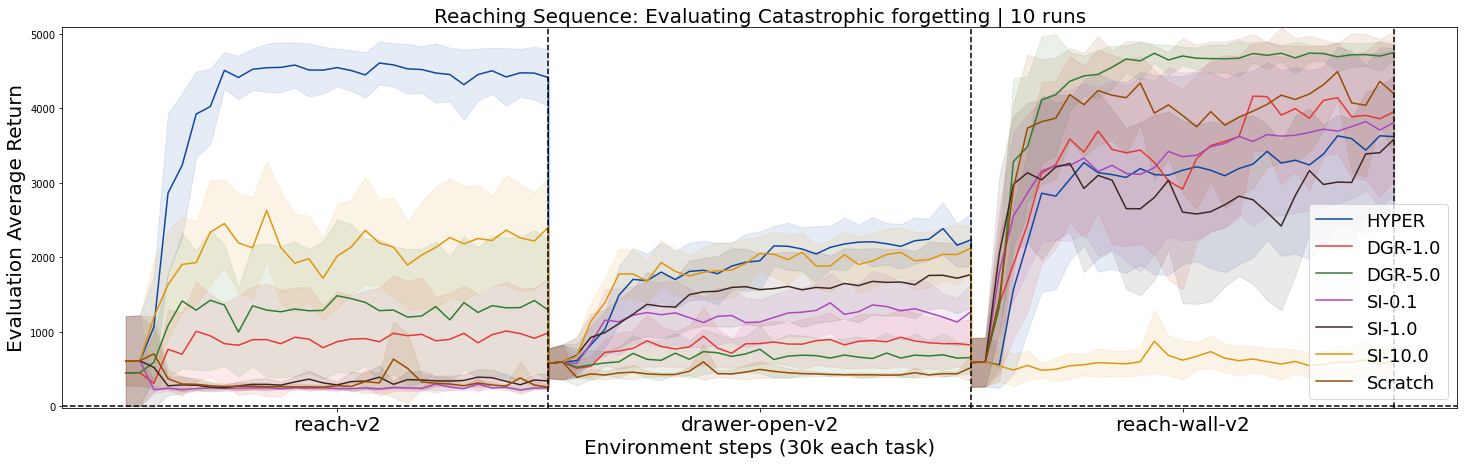

In [107]:
# Prepare data for all algorithms
stuff_all_curves = [
    # compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual_compare, 'average_true_episode_return_final'),
    compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual_beta07_compare, 'average_true_episode_return_final'),
    compute_tuple_eval(path_DGR_seq2_fixed_goals_actual, 'average_true_episode_return_final'),
    compute_tuple_eval(path_DGR_seq2_fixed_goals_actual_beta05, 'average_true_episode_return_final'),
    compute_tuple_eval(path_SI_seq2_fixed_goals_actual, 'average_true_episode_return_final'),
    compute_tuple_eval(path_SI_seq2_fixed_goals_actual_beta1, 'average_true_episode_return_final'),
    compute_tuple_eval(path_SI_seq2_fixed_goals_actual_beta10, 'average_true_episode_return_final'),
    compute_tuple_eval(path_scratch, 'average_true_episode_return_final'),
    # compute_tuple_eval(path_PEBBLE, 'average_true_episode_return_final'),
    # compute_tuple_eval(path_oracle_seq2_fixed_goals_actual, 'average_true_episode_return'),
    # compute_tuple_eval(path_HYPER_seq4_fixed_goals_actual_small_emb_lr, 'average_true_episode_return'),
    # compute_tuple_eval(path_HYPER_seq4_fixed_goals_actual_compare, 'average_true_episode_return_final'),
    # compute_tuple_eval(path_HYPER_seq4_fixed_goals_actual_beta07_compare, 'average_true_episode_return_final'),
    # compute_tuple_eval(path_HYPER_seq4_small_embhnet_lr, 'average_true_episode_return'),
    # compute_tuple_eval(path_oracle_seq4_fixed_goals_actual, 'average_true_episode_return')
    # compute_tuple_train(path_oracle_seq4_small_lr, 'true_episode_return')
    
    

]
stuff_all_curves = np.array(stuff_all_curves)

print(stuff_all_curves.shape)

# legend = ['0.001', '0.0003-0.75', '0.0003-0.50', '0.0003-0.25', 'oracle']
legend = [
    # 'HYPER-Seq-2',
    'HYPER',
    'DGR-1.0',
    'DGR-5.0',
    'SI-0.1',
    'SI-1.0',
    'SI-10.0',
    'Scratch',
    # 'PEBBLE',
    # 'HYPER-Seq-4-small-emb-lr',

    # 'HYPER-Seq-4',
    # 'HYPER-Seq-4-larger-beta',
    # 'HYPER-smaller-emb-lr-Seq-4',
    # 'oracle-Seq-4',
    # "oracle-small-lr"
]
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC', '#3E2723', '#DE970B', '#964B00', '#FF00FF', '#8B0000', '#4682B4', '#FFD700']
title = f'Reaching Sequence: Evaluating Catastrophic forgetting | 10 runs'
xylabels = ['Environment steps (30k each task)', 'Evaluation Average Return']

plot_single(
    steps_plot,
    stuff_all_curves,
    legend,
    colors,
    title,
    figsize,
    xylabels,
    plot_mu_ci,
    lims,
    t_value,
    vert_lines=vert_lines,
    hor_lines=hor_lines,
    x_ticks=x_ticks,
    x_labels=x_labels,
    summarize_plot=True
)

# Eval: DGR

(3, 10, 93)


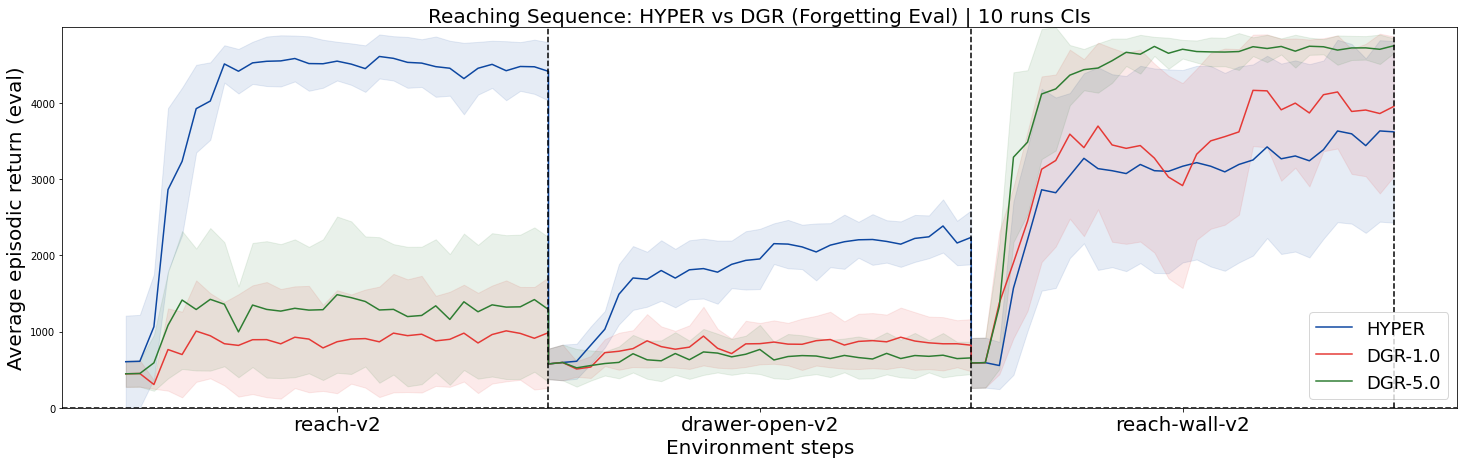

In [103]:
# Prepare data for all algorithms
stuff_all_curves = [
    # compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual_compare, 'average_true_episode_return_final'),
    compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual_beta07_compare, 'average_true_episode_return_final'),
    compute_tuple_eval(path_DGR_seq2_fixed_goals_actual, 'average_true_episode_return_final'),
    compute_tuple_eval(path_DGR_seq2_fixed_goals_actual_beta05, 'average_true_episode_return_final'),
    # compute_tuple_eval(path_SI_seq2_fixed_goals_actual, 'average_true_episode_return_final'),
    # compute_tuple_eval(path_SI_seq2_fixed_goals_actual_beta1, 'average_true_episode_return_final'),
    # compute_tuple_eval(path_SI_seq2_fixed_goals_actual_beta10, 'average_true_episode_return_final'),

    # compute_tuple_eval(path_oracle_seq2_fixed_goals_actual, 'average_true_episode_return'),
    # compute_tuple_eval(path_HYPER_seq4_fixed_goals_actual_small_emb_lr, 'average_true_episode_return'),
    # compute_tuple_eval(path_HYPER_seq4_fixed_goals_actual_compare, 'average_true_episode_return_final'),
    # compute_tuple_eval(path_HYPER_seq4_fixed_goals_actual_beta07_compare, 'average_true_episode_return_final'),
    # compute_tuple_eval(path_HYPER_seq4_small_embhnet_lr, 'average_true_episode_return'),
    # compute_tuple_eval(path_oracle_seq4_fixed_goals_actual, 'average_true_episode_return')
    # compute_tuple_train(path_oracle_seq4_small_lr, 'true_episode_return')
    
    

]
stuff_all_curves = np.array(stuff_all_curves)

print(stuff_all_curves.shape)

# legend = ['0.001', '0.0003-0.75', '0.0003-0.50', '0.0003-0.25', 'oracle']
legend = [
    # 'HYPER-Seq-2',
    'HYPER',
    'DGR-1.0',
    'DGR-5.0',
    # 'SI-beta-0.1',
    # 'SI-beta-1.0',
    # 'SI-beta-10.0',
    # 'HYPER-Seq-4-small-emb-lr',

    # 'HYPER-Seq-4',
    # 'HYPER-Seq-4-larger-beta',
    # 'HYPER-smaller-emb-lr-Seq-4',
    # 'oracle-Seq-4',
    # "oracle-small-lr"
]
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC', '#3E2723', '#DE970B', '#964B00', '#FF00FF', '#8B0000', '#4682B4', '#FFD700']
title = f'Reaching Sequence: HYPER vs DGR (Forgetting Eval) | {num_runs} runs CIs'
xylabels = ['Environment steps', 'Average episodic return (eval)']

plot_single(
    steps_plot,
    stuff_all_curves,
    legend,
    colors,
    title,
    figsize,
    xylabels,
    plot_mu_ci,
    lims,
    t_value,
    vert_lines=vert_lines,
    hor_lines=hor_lines,
    x_ticks=x_ticks,
    x_labels=x_labels,
    summarize_plot=False
)

In [104]:
# Prepare a list of (path, array) tuples for sorting
curve_data = [
    (path_03_75, stuff_all_curves_03_075_01),
    (path_03_75_01, stuff_all_curves_03_075_01),
    (path_03_75_1, stuff_all_curves_03_075_1),
    (path_03_25, stuff_all_curves_03_25),
    (path_03_25_01, stuff_all_curves_03_25_01),
    (path_03_25_1, stuff_all_curves_03_25_1),
    (path_03_50, stuff_all_curves_03_50),
    (path_03_50_01, stuff_all_curves_03_50_01),
    (path_03_50_1, stuff_all_curves_03_50_1),
    (path_SI_01, stuff_all_curves_SI_01),
    (path_SI_1, stuff_all_curves_SI_1),
    (path_SI_10, stuff_all_curves_SI_10),
    (path_DGR_1, stuff_all_curves_DGR_1),
    (path_DGR_5, stuff_all_curves_DGR_5),
    (path_oracle, stuff_all_curves_oracle)
]

# Compute mean and variance for each
stats = []
for p, arr in curve_data:
    mean = np.mean(arr)
    var = np.var(arr, ddof=1)
    stats.append((p, mean, var))

# Sort by mean (ascending)
sorted_by_mean = sorted(stats, key=lambda x: x[1])
print("Sorted by mean:")
for p, mean, var in sorted_by_mean:
    print(f"Hyperparameters: {p}\n  Mean: {mean:.2f}  Variance: {var:.2f}")

# Sort by variance (ascending)
sorted_by_var = sorted(stats, key=lambda x: x[2])
print("\nSorted by variance:")
for p, mean, var in sorted_by_var:
    print(f"Path: {p}\n  Variance: {var:.2f}  Mean: {mean:.2f}")

# Consolidated list sorted by mean/sqrt(variance)
mean_sqrtvar_stats = []
for p, arr in curve_data:
    mean = np.mean(arr)
    var = np.var(arr, ddof=1)
    score = mean / np.sqrt(var) if var > 0 else float('inf')
    # score = mean / (var) if var > 0 else float('inf')
    mean_sqrtvar_stats.append((p, mean, var, score))

sorted_by_score = sorted(mean_sqrtvar_stats, key=lambda x: x[3], reverse=True)
print("\nSorted by mean/sqrt(variance):")
for p, mean, var, score in sorted_by_score:
    print(f"Path: {p}\n  Mean: {mean:.2f}  Variance: {var:.2f}  Mean/sqrt(Var): {score:.2f}")



NameError: name 'path_03_75' is not defined

In [ ]:
print("stuff_all_curves_03_075_01")
print(np.mean(stuff_all_curves_03_075_01), np.std(stuff_all_curves_03_075_01, ddof=1))

print("stuff_all_curves_03_075_1")
print(np.mean(stuff_all_curves_03_075_1), np.std(stuff_all_curves_03_075_1, ddof=1))

print("stuff_all_curves_03_25")
print(np.mean(stuff_all_curves_03_25), np.std(stuff_all_curves_03_25, ddof=1))

print("stuff_all_curves_03_25_01")
print(np.mean(stuff_all_curves_03_25_01), np.std(stuff_all_curves_03_25_01, ddof=1))

print("stuff_all_curves_03_25_1")
print(np.mean(stuff_all_curves_03_25_1), np.std(stuff_all_curves_03_25_1, ddof=1))

print("stuff_all_curves_03_50")
print(np.mean(stuff_all_curves_03_50), np.std(stuff_all_curves_03_50, ddof=1))

print("stuff_all_curves_03_50_01")
print(np.mean(stuff_all_curves_03_50_01), np.std(stuff_all_curves_03_50_01, ddof=1))

print("stuff_all_curves_03_50_1")
print(np.mean(stuff_all_curves_03_50_1), np.std(stuff_all_curves_03_50_1, ddof=1))

print("stuff_all_curves_DGR")
print(np.mean(stuff_all_curves_DGR), np.std(stuff_all_curves_DGR, ddof=1))

print("stuff_all_curves_oracle")
print(np.mean(stuff_all_curves_oracle), np.std(stuff_all_curves_oracle, ddof=1))

stuff_all_curves_03_075_01
-845.98079009547 412.023639187613
stuff_all_curves_03_075_1
-749.6581527471279 439.17709410334504
stuff_all_curves_03_25
-912.4121381264789 423.4322002541996
stuff_all_curves_03_25_01
-878.4504511343229 409.6100675251885
stuff_all_curves_03_25_1
-775.5050798172452 393.35137698259786
stuff_all_curves_03_50
-868.0681608849944 419.0149078319047
stuff_all_curves_03_50_01
-839.0990212950069 417.53236600573604
stuff_all_curves_03_50_1
-1075.5237267870507 619.2626417606016
stuff_all_curves_DGR
-743.2601630824614 354.6275631714698
stuff_all_curves_oracle
-142.95220704820878 295.9466374617478


In [ ]:
for i in range(stuff_all_curves_oracle.shape[0]):
    print(np.mean(stuff_all_curves_oracle[i]), np.std(stuff_all_curves_oracle[i], ddof=1))

for i in range(stuff_all_curves_03_50.shape[0]):
    print(np.mean(stuff_all_curves_03_50[i]), np.std(stuff_all_curves_03_50[i], ddof=1))
    
for i in range(stuff_all_curves_03_075.shape[0]):
    print(np.mean(stuff_all_curves_03_075[i]), np.std(stuff_all_curves_03_075[i], ddof=1))

-142.42122712337058 297.1236621874765
-143.48318697304697 295.3772277401765
-756.2944080791328 376.2964792032285
-979.841913690856 430.75736137154445
-743.2601630824614 354.6275631714698


# learned episode return vs step

In [ ]:
stuff_all_curves = [
    compute_tuple_train(path_1, 'learned_episode_return'),
    # compute_tuple_eval(path_DGR, 'average_true_episode_return'),
    compute_tuple_train(path_03, 'learned_episode_return'),
    # compute_tuple_train(path_oracle, 'learned_episode_return')
]
stuff_all_curves = np.array(stuff_all_curves)

legend = ['0.001', '0.0003']
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC']
title = f'Continual RL Algorithms Comparison | {num_runs} runs CIs'
xylabels = ['Environment steps', 'Average episodic return\n(15 episodes every 10K steps)']

plot_single(
    steps_plot_train,
    stuff_all_curves,
    legend,
    colors,
    title,
    figsize,
    xylabels,
    plot_mu_ci,
    lims,
    t_value,
    vert_lines=vert_lines,
    hor_lines=hor_lines,
    x_ticks=x_ticks,
    x_labels=x_labels,
    summarize_plot=False
)

/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.001/reg_beta_0.75/continual_train/Run_1/train.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.001/reg_beta_0.75/continual_train/Run_2/train.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.0003/reg_beta_0.75/continual_train/Run_1/train.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.0003/reg_beta_0.75/continual_train/Run_2/train.csv


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 2) + inhomogeneous part.

/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.001/reg_beta_0.75/continual_train/Run_1/train.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.0003/reg_beta_0.75/continual_train/Run_1/train.csv


/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/.CPRL_venv/lib/python3.10/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/.CPRL_venv/lib/python3.10/site-packages/numpy/core/_methods.py:258: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/.CPRL_venv/lib/python3.10/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/.CPRL_venv/lib/python3.10/site-packages/numpy/core/_methods.py:258: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


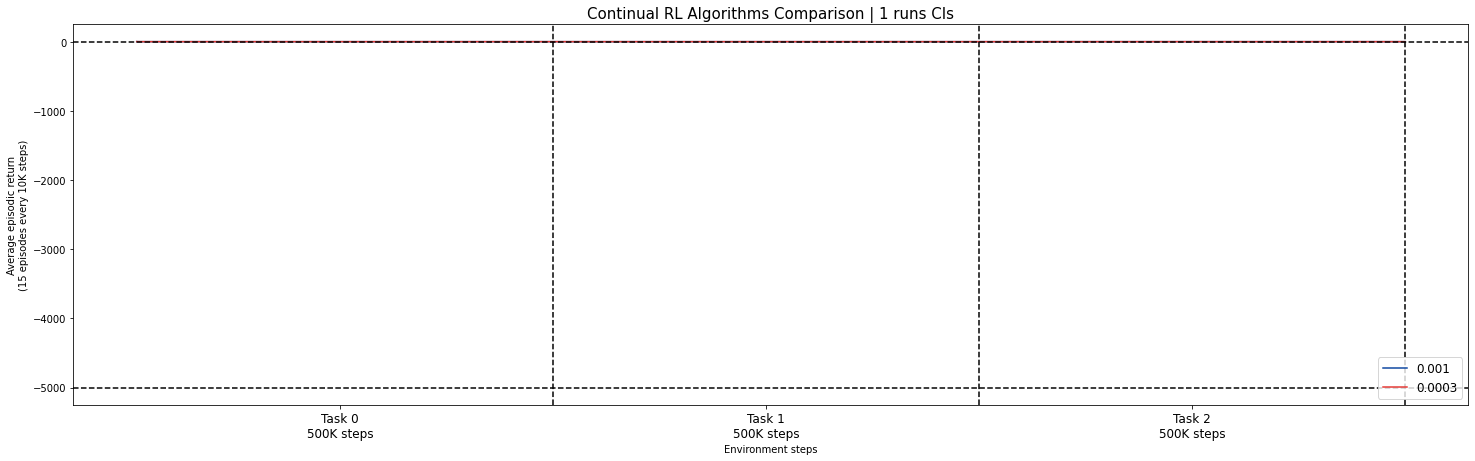

In [ ]:
stuff_all_curves = [
    compute_tuple_train(path_1, 'rew_adaptation_acc'),
    # compute_tuple_eval(path_DGR, 'average_true_episode_return'),
    compute_tuple_train(path_03, 'rew_adaptation_acc'),
    # compute_tuple_eval(path_ER, 'average_true_episode_return')
]
stuff_all_curves = np.array(stuff_all_curves)

legend = ['0.001', '0.0003']
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC']
title = f'Continual RL Algorithms Comparison | {num_runs} runs CIs'
xylabels = ['Environment steps', 'Average episodic return\n(15 episodes every 10K steps)']

plot_single(
    steps_plot_train,
    stuff_all_curves,
    legend,
    colors,
    title,
    figsize,
    xylabels,
    plot_mu_ci,
    lims,
    t_value,
    vert_lines=vert_lines,
    hor_lines=hor_lines,
    x_ticks=x_ticks,
    x_labels=x_labels,
    summarize_plot=False
)